In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import cv2
import os
from collections import Counter
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Dataset and Preprocessing


Contents of dataset directory:
Found folders: ['dog', 'panda', 'cat']
Folder 'dog': 100 images
Folder 'panda': 100 images
Folder 'cat': 100 images

Loading and preprocessing images from nested structure...
Found 3 classes: ['cat', 'dog', 'panda']
Class 'cat': loaded 100 images
Class 'dog': loaded 100 images
Class 'panda': loaded 100 images

Total data shape: (300, 1024)
Total labels shape: (300,)
Class names: ['cat', 'dog', 'panda']

Class distribution:
  cat: 100 images
  dog: 100 images
  panda: 100 images

Training data shape: (240, 1024)
Test data shape: (60, 1024)

Sample training images:


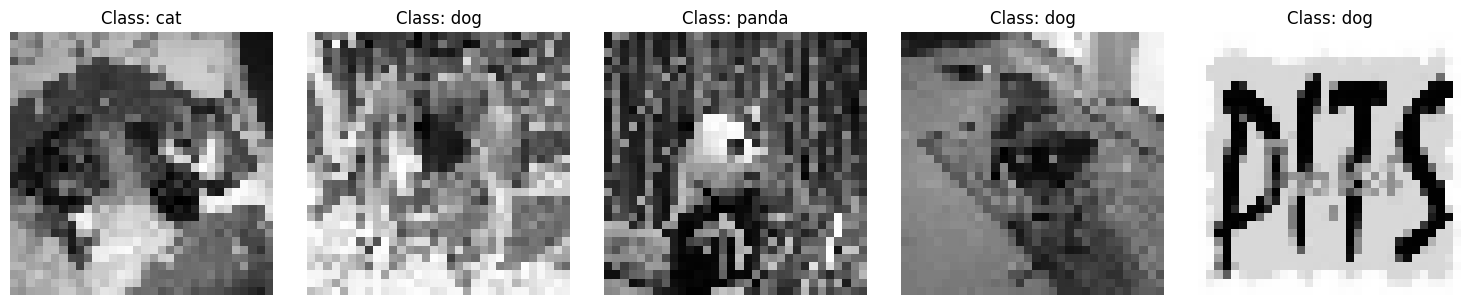

In [6]:
# Define dataset paths for Kaggle
dataset_path = '/kaggle/input/animal-dataset/animal_dataset'

# Check what's in the directory
print("Contents of dataset directory:")
if os.path.exists(dataset_path):
    contents = os.listdir(dataset_path)
    print(f"Found folders: {contents}")
    
    # Check each folder to see if they contain images
    for folder in contents:
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"Folder '{folder}': {len(image_files)} images")
else:
    print(f"Directory {dataset_path} not found!")

# Function to load and preprocess images from nested structure
def load_and_preprocess_images_from_nested(root_path, img_size=(32, 32)):
    images = []
    labels = []
    class_names = []
    
    if not os.path.exists(root_path):
        print(f"Error: Root path {root_path} does not exist!")
        return np.array(images), np.array(labels), class_names
    
    # Get all subdirectories (classes)
    items = os.listdir(root_path)
    class_folders = [item for item in items if os.path.isdir(os.path.join(root_path, item))]
    class_folders.sort()
    
    print(f"Found {len(class_folders)} classes: {class_folders}")
    
    for class_idx, class_folder in enumerate(class_folders):
        class_path = os.path.join(root_path, class_folder)
        image_count = 0
        
        # Get all files in the class folder
        files = os.listdir(class_path)
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            
            try:
                # Load image
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Warning: Could not load {img_path}")
                    continue
                
                # Convert to grayscale
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                
                # Resize to 32x32
                img_resized = cv2.resize(img_gray, img_size)
                
                # Flatten the image
                img_flattened = img_resized.flatten()
                
                images.append(img_flattened)
                labels.append(class_idx)
                image_count += 1
                
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        print(f"Class '{class_folder}': loaded {image_count} images")
        class_names.append(class_folder)
    
    return np.array(images), np.array(labels), class_names

# Load all data from the nested structure
print("\nLoading and preprocessing images from nested structure...")
X_all, y_all, class_names = load_and_preprocess_images_from_nested(dataset_path)

# Check if data was loaded successfully
if len(X_all) == 0:
    print("Error: No images were loaded. Please check the dataset structure.")
else:
    print(f"\nTotal data shape: {X_all.shape}")
    print(f"Total labels shape: {y_all.shape}")
    print(f"Class names: {class_names}")
    
    # Display class distribution
    unique, counts = np.unique(y_all, return_counts=True)
    print("\nClass distribution:")
    for class_idx, count in zip(unique, counts):
        print(f"  {class_names[class_idx]}: {count} images")
    
    # Split into train and test sets (80/20 split)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )
    
    print(f"\nTraining data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")
    
    # Normalize the pixel values (0-255 to 0-1)
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Display sample images
    def display_sample_images(images, labels, class_names, num_samples=5):
        plt.figure(figsize=(15, 3))
        for i in range(min(num_samples, len(images))):
            plt.subplot(1, num_samples, i + 1)
            # Reshape back to 32x32 for display
            img = images[i].reshape(32, 32)
            plt.imshow(img, cmap='gray')
            plt.title(f'Class: {class_names[labels[i]]}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    print("\nSample training images:")
    display_sample_images(X_train, y_train, class_names)

# Model Building and Evaluation


In [7]:
# Only run if data was loaded successfully
if len(X_train) > 0 and len(X_test) > 0:
    # Define K values to test
    k_values = list(range(1, 16, 2))  # Odd values from 1 to 15

    # Initialize results storage
    results_l1 = {k: [] for k in k_values}
    results_l2 = {k: [] for k in k_values}

    # 5-fold cross-validation
    print("Starting 5-fold cross-validation...")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"\n--- Fold {fold + 1} ---")
        
        # Split data for this fold
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        for k in k_values:
            # KNN with Manhattan distance (L1)
            knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
            knn_l1.fit(X_fold_train, y_fold_train)
            y_pred_l1 = knn_l1.predict(X_fold_val)
            acc_l1 = accuracy_score(y_fold_val, y_pred_l1)
            results_l1[k].append(acc_l1)
            
            # KNN with Euclidean distance (L2)
            knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
            knn_l2.fit(X_fold_train, y_fold_train)
            y_pred_l2 = knn_l2.predict(X_fold_val)
            acc_l2 = accuracy_score(y_fold_val, y_pred_l2)
            results_l2[k].append(acc_l2)
            
            if k in [1, 5, 9, 13]:  # Print only specific K values to reduce output
                print(f"K={k}: L1={acc_l1:.4f}, L2={acc_l2:.4f}")

    # Calculate average accuracy for each K
    avg_results_l1 = {k: np.mean(accuracies) for k, accuracies in results_l1.items()}
    avg_results_l2 = {k: np.mean(accuracies) for k, accuracies in results_l2.items()}

    print("\nAverage accuracies across 5 folds:")
    for k in k_values:
        print(f"K={k}: L1={avg_results_l1[k]:.4f}, L2={avg_results_l2[k]:.4f}")
else:
    print("Skipping model building due to missing data.")

Starting 5-fold cross-validation...

--- Fold 1 ---
K=1: L1=0.4792, L2=0.4167
K=5: L1=0.3958, L2=0.3750
K=9: L1=0.4792, L2=0.3333
K=13: L1=0.4375, L2=0.3750

--- Fold 2 ---
K=1: L1=0.4375, L2=0.3542
K=5: L1=0.4167, L2=0.3750
K=9: L1=0.4792, L2=0.4583
K=13: L1=0.5625, L2=0.4583

--- Fold 3 ---
K=1: L1=0.5000, L2=0.4583
K=5: L1=0.3542, L2=0.3958
K=9: L1=0.3333, L2=0.3125
K=13: L1=0.3958, L2=0.3333

--- Fold 4 ---
K=1: L1=0.3333, L2=0.3125
K=5: L1=0.2708, L2=0.3125
K=9: L1=0.3958, L2=0.2917
K=13: L1=0.3750, L2=0.3542

--- Fold 5 ---
K=1: L1=0.3750, L2=0.3542
K=5: L1=0.4167, L2=0.4583
K=9: L1=0.3958, L2=0.3542
K=13: L1=0.3958, L2=0.4167

Average accuracies across 5 folds:
K=1: L1=0.4250, L2=0.3792
K=3: L1=0.3917, L2=0.3708
K=5: L1=0.3708, L2=0.3833
K=7: L1=0.4167, L2=0.3542
K=9: L1=0.4167, L2=0.3500
K=11: L1=0.4000, L2=0.3583
K=13: L1=0.4333, L2=0.3875
K=15: L1=0.4417, L2=0.3708


# Results and Analysis


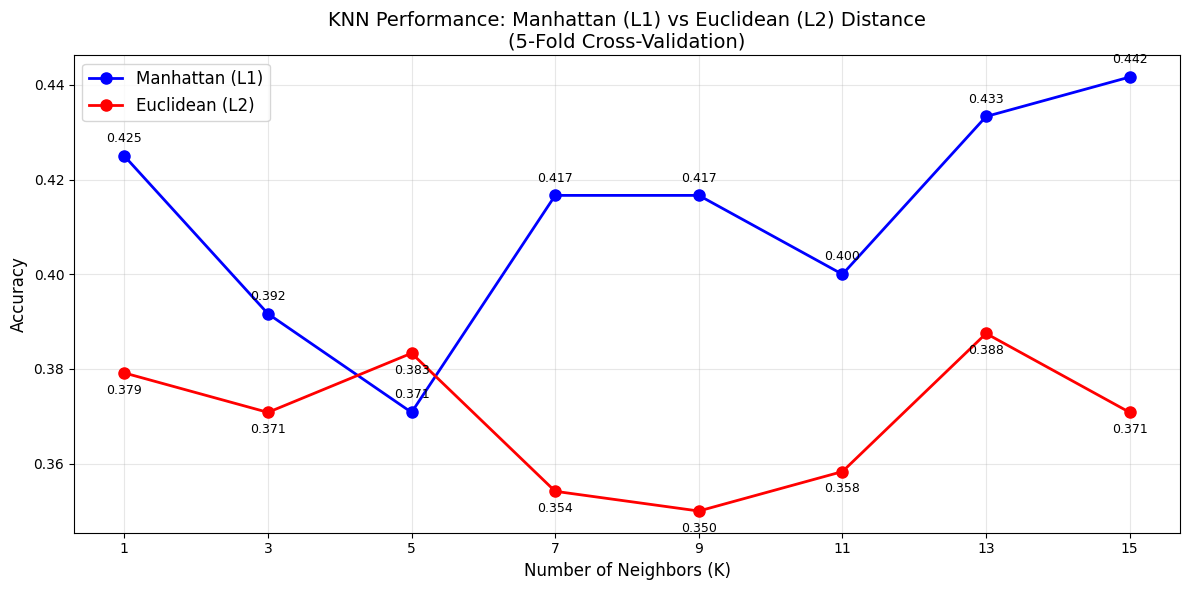


Best performance:
Manhattan (L1): K=15, Accuracy=0.4417
Euclidean (L2): K=13, Accuracy=0.3875


In [8]:
if len(X_train) > 0 and len(X_test) > 0:
    # Plot the results
    plt.figure(figsize=(12, 6))

    # Convert results to lists for plotting
    k_list = list(avg_results_l1.keys())
    l1_scores = [avg_results_l1[k] for k in k_list]
    l2_scores = [avg_results_l2[k] for k in k_list]

    plt.plot(k_list, l1_scores, 'bo-', linewidth=2, markersize=8, label='Manhattan (L1)')
    plt.plot(k_list, l2_scores, 'ro-', linewidth=2, markersize=8, label='Euclidean (L2)')

    plt.xlabel('Number of Neighbors (K)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('KNN Performance: Manhattan (L1) vs Euclidean (L2) Distance\n(5-Fold Cross-Validation)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_list)

    # Add value annotations on points
    for i, (k, l1_acc, l2_acc) in enumerate(zip(k_list, l1_scores, l2_scores)):
        plt.annotate(f'{l1_acc:.3f}', (k, l1_acc), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{l2_acc:.3f}', (k, l2_acc), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Find best K for each distance metric
    best_k_l1 = max(avg_results_l1, key=avg_results_l1.get)
    best_k_l2 = max(avg_results_l2, key=avg_results_l2.get)

    best_acc_l1 = avg_results_l1[best_k_l1]
    best_acc_l2 = avg_results_l2[best_k_l2]

    print(f"\nBest performance:")
    print(f"Manhattan (L1): K={best_k_l1}, Accuracy={best_acc_l1:.4f}")
    print(f"Euclidean (L2): K={best_k_l2}, Accuracy={best_acc_l2:.4f}")

# Discussion


In [9]:
if len(X_train) > 0 and len(X_test) > 0:
    # Discussion and analysis
    print("="*80)
    print("DISCUSSION")
    print("="*80)

    print(f"\nPerformance Comparison:")
    print(f"- Manhattan (L1) distance achieved best accuracy of {best_acc_l1:.4f} with K={best_k_l1}")
    print(f"- Euclidean (L2) distance achieved best accuracy of {best_acc_l2:.4f} with K={best_k_l2}")

    # Determine which distance metric performed better
    if best_acc_l1 > best_acc_l2:
        better_metric = "Manhattan (L1)"
        performance_diff = best_acc_l1 - best_acc_l2
    elif best_acc_l2 > best_acc_l1:
        better_metric = "Euclidean (L2)"
        performance_diff = best_acc_l2 - best_acc_l1
    else:
        better_metric = "Both performed equally"
        performance_diff = 0

    print(f"\nOverall Best Performing Metric: {better_metric}")
    if performance_diff > 0:
        print(f"Performance difference: {performance_diff:.4f}")

    print(f"\nAnalysis:")
    print("1. Distance Metric Characteristics:")
    print("   - Manhattan (L1): More robust to outliers, works well with high-dimensional data")
    print("   - Euclidean (L2): Considers geometric distance, sensitive to feature scales")

    print("\n2. Dataset Characteristics:")
    print(f"   - Number of classes: {len(class_names)}")
    print(f"   - Classes: {', '.join(class_names)}")
    print(f"   - Total images: {len(X_all)}")
    print(f"   - Training images: {len(X_train)}")
    print(f"   - Test images: {len(X_test)}")
    print(f"   - Feature dimension: {X_train.shape[1]} (32x32 grayscale)")

    print("\n3. K Value Impact:")
    print("   - Smaller K values (1, 3): More sensitive to noise but can capture local patterns")
    print("   - Larger K values (9+): More stable but may oversmooth decision boundaries")

    print("\n4. Potential Improvements:")
    print("   - Feature selection/dimensionality reduction (PCA)")
    print("   - Different preprocessing techniques (histogram equalization)")
    print("   - Ensemble methods combining both distance metrics")
    print("   - Hyperparameter tuning with wider K range")

DISCUSSION

Performance Comparison:
- Manhattan (L1) distance achieved best accuracy of 0.4417 with K=15
- Euclidean (L2) distance achieved best accuracy of 0.3875 with K=13

Overall Best Performing Metric: Manhattan (L1)
Performance difference: 0.0542

Analysis:
1. Distance Metric Characteristics:
   - Manhattan (L1): More robust to outliers, works well with high-dimensional data
   - Euclidean (L2): Considers geometric distance, sensitive to feature scales

2. Dataset Characteristics:
   - Number of classes: 3
   - Classes: cat, dog, panda
   - Total images: 300
   - Training images: 240
   - Test images: 60
   - Feature dimension: 1024 (32x32 grayscale)

3. K Value Impact:
   - Smaller K values (1, 3): More sensitive to noise but can capture local patterns
   - Larger K values (9+): More stable but may oversmooth decision boundaries

4. Potential Improvements:
   - Feature selection/dimensionality reduction (PCA)
   - Different preprocessing techniques (histogram equalization)
   - 

# Top 5 Predictions



TOP 5 PREDICTIONS
Using Manhattan (L1) distance with K=15 for final predictions

Final Model Test Accuracy: 0.3833

Top 5 Predictions on Test Set:
------------------------------------------------------------


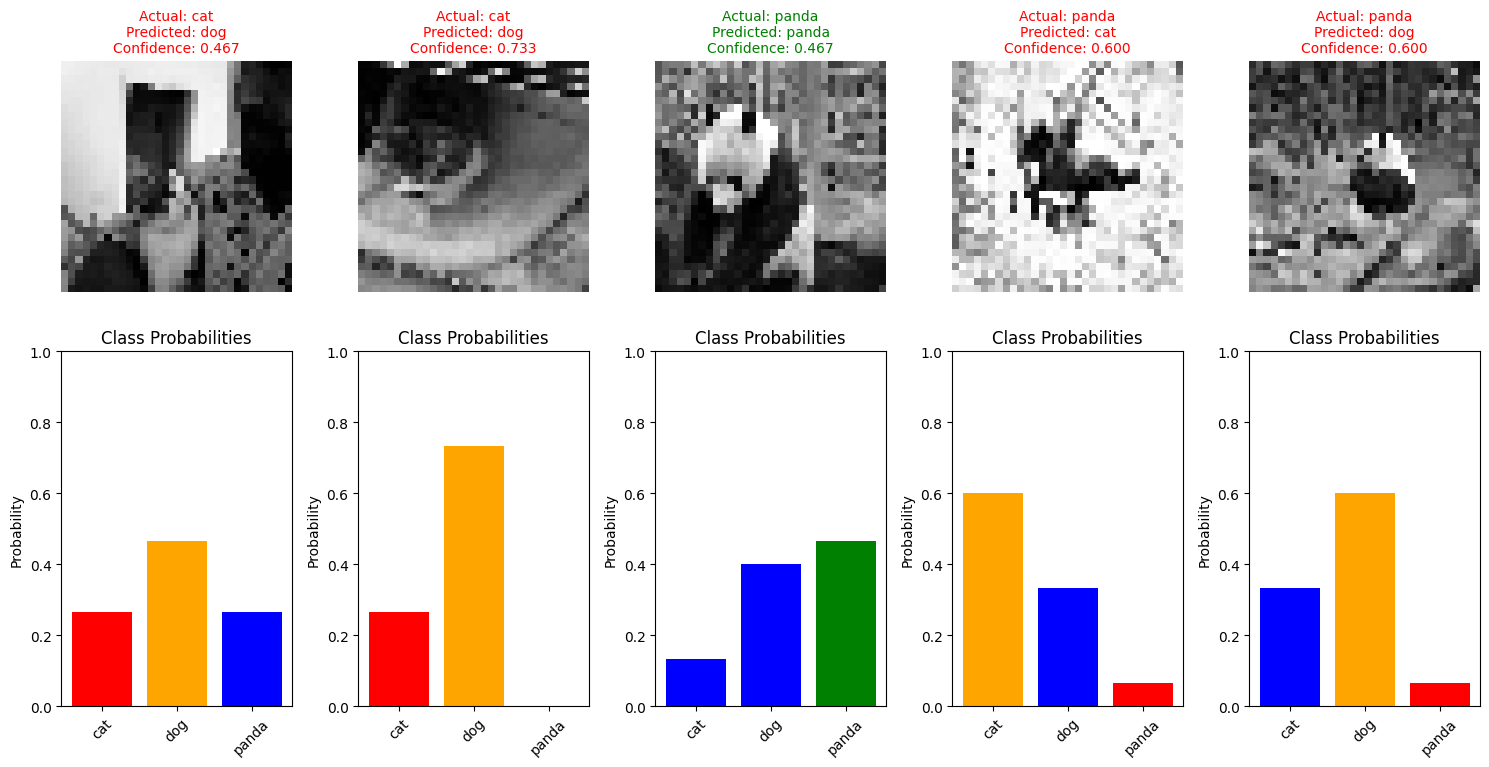


Detailed Prediction Information:
--------------------------------------------------
Sample 1:
  Actual: cat
  Predicted: dog (Confidence: 0.467)
  Status: ✗ WRONG
  Top 3 probabilities:
    dog: 0.467
    panda: 0.267
    cat: 0.267

Sample 2:
  Actual: cat
  Predicted: dog (Confidence: 0.733)
  Status: ✗ WRONG
  Top 3 probabilities:
    dog: 0.733
    cat: 0.267
    panda: 0.000

Sample 3:
  Actual: panda
  Predicted: panda (Confidence: 0.467)
  Status: ✓ CORRECT
  Top 3 probabilities:
    panda: 0.467
    dog: 0.400
    cat: 0.133

Sample 4:
  Actual: panda
  Predicted: cat (Confidence: 0.600)
  Status: ✗ WRONG
  Top 3 probabilities:
    cat: 0.600
    dog: 0.333
    panda: 0.067

Sample 5:
  Actual: panda
  Predicted: dog (Confidence: 0.600)
  Status: ✗ WRONG
  Top 3 probabilities:
    dog: 0.600
    cat: 0.333
    panda: 0.067

FINAL SUMMARY
Dataset: Animal Classification
Classes: cat, dog, panda
Best Distance Metric: Manhattan (L1)
Optimal K Value: 15
Cross-Validation Accuracy: 0

In [10]:
if len(X_train) > 0 and len(X_test) > 0:
    # Train final model with best parameters
    print("\n" + "="*80)
    print("TOP 5 PREDICTIONS")
    print("="*80)

    # Use the best performing distance metric for final model
    if best_acc_l1 >= best_acc_l2:
        best_metric = 'manhattan'
        best_k = best_k_l1
        print(f"Using Manhattan (L1) distance with K={best_k} for final predictions")
    else:
        best_metric = 'euclidean'
        best_k = best_k_l2
        print(f"Using Euclidean (L2) distance with K={best_k} for final predictions")

    # Train final model on entire training set
    final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    final_knn.fit(X_train, y_train)

    # Make predictions on test set
    y_test_pred = final_knn.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\nFinal Model Test Accuracy: {test_accuracy:.4f}")

    # Get prediction probabilities for top predictions
    y_test_proba = final_knn.predict_proba(X_test)

    # Display top 5 predictions with confidence scores
    print(f"\nTop 5 Predictions on Test Set:")
    print("-" * 60)

    plt.figure(figsize=(15, 8))
    for i in range(min(5, len(X_test))):
        plt.subplot(2, 5, i + 1)
        
        # Display original image
        img = X_test[i].reshape(32, 32)
        plt.imshow(img, cmap='gray')
        
        actual_class = class_names[y_test[i]]
        predicted_class = class_names[y_test_pred[i]]
        confidence = np.max(y_test_proba[i])
        
        # Color code: green if correct, red if wrong
        color = 'green' if y_test[i] == y_test_pred[i] else 'red'
        
        plt.title(f'Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.3f}', 
                  color=color, fontsize=10)
        plt.axis('off')
        
        # Display probability distribution
        plt.subplot(2, 5, i + 6)
        classes = range(len(class_names))
        colors = []
        for j in classes:
            if j == y_test[i] and j == y_test_pred[i]:
                colors.append('green')  # Correct prediction
            elif j == y_test[i]:
                colors.append('red')    # Actual class but wrong prediction
            elif j == y_test_pred[i]:
                colors.append('orange') # Predicted class but wrong
            else:
                colors.append('blue')   # Other classes
        
        plt.bar(classes, y_test_proba[i], color=colors)
        plt.xticks(classes, class_names, rotation=45)
        plt.title('Class Probabilities')
        plt.ylabel('Probability')
        plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Detailed prediction information
    print("\nDetailed Prediction Information:")
    print("-" * 50)
    for i in range(min(5, len(X_test))):
        actual_class = class_names[y_test[i]]
        predicted_class = class_names[y_test_pred[i]]
        confidence = np.max(y_test_proba[i])
        status = "✓ CORRECT" if y_test[i] == y_test_pred[i] else "✗ WRONG"
        
        print(f"Sample {i+1}:")
        print(f"  Actual: {actual_class}")
        print(f"  Predicted: {predicted_class} (Confidence: {confidence:.3f})")
        print(f"  Status: {status}")
        # Show top 3 probabilities
        top3_idx = np.argsort(y_test_proba[i])[-3:][::-1]
        print(f"  Top 3 probabilities:")
        for idx in top3_idx:
            print(f"    {class_names[idx]}: {y_test_proba[i][idx]:.3f}")
        print()

    # Overall performance summary
    print("="*80)
    print("FINAL SUMMARY")
    print("="*80)
    print(f"Dataset: Animal Classification")
    print(f"Classes: {', '.join(class_names)}")
    print(f"Best Distance Metric: {better_metric}")
    print(f"Optimal K Value: {best_k}")
    print(f"Cross-Validation Accuracy: {max(best_acc_l1, best_acc_l2):.4f}")
    print(f"Test Set Accuracy: {test_accuracy:.4f}")
    print(f"Number of Classes: {len(class_names)}")
    print(f"Total Images: {len(X_all)}")
    print(f"Training Images: {len(X_train)}")
    print(f"Test Images: {len(X_test)}")
    print(f"Feature Dimension: {X_train.shape[1]} (32x32 grayscale)")
else:
    print("Cannot generate predictions due to missing data.")